In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.unicode_minus"] = False

In [10]:
from google.colab import files
yuklenen = files.upload()
dosya = list(yuklenen.keys())[0]

# Dosyayı sadece sütunları ayırarak oku, biçim ayarı yapma
df = pd.read_csv(dosya, sep=",", dtype=str)

# Sayıları temizleyip güvenli şekilde dönüştür
def sayiya_cevir(deger):
    if pd.isna(deger):
        return 0.0
    s = str(deger).strip().replace(" ", "")
    if s == "":
        return 0.0
    # Virgülü noktaya çevir, sayıya dönüştür
    try:
        return float(s.replace(",", "."))
    except:
        return 0.0

sutunlar = ["Deger_USD", "Ihracat_USD", "Ithalat_USD", "Ticaret_Dengesi"]
for s in sutunlar:
    df[s] = df[s].apply(sayiya_cevir)

# Kontrol
print(df[sutunlar].dtypes)
df.head()

Saving turkiye_dış_ticaret - turkiye_dış_ticaret.csv to turkiye_dış_ticaret - turkiye_dış_ticaret (3).csv
Deger_USD          float64
Ihracat_USD        float64
Ithalat_USD        float64
Ticaret_Dengesi    float64
dtype: object


,YIL,Ticaret_Turu,Ulke,Urun_Gurubu,Deger_USD,Ihracat_USD,Ithalat_USD,Ticaret_Dengesi
0,2021,Import,Saudi Arabia,"Coffee, tea, mate and spices",1.112592e+08,0.0,1.112592e+08,-1.112592e+08
1,2021,Import,Luxembourg,Iron and steel,2.781867e+09,0.0,2.781867e+09,-2.781867e+09
2,2021,Export,North Macedonia,"Optical, photographic, cinematographic, measur...",2.972655e+06,2972655.0,0.000000e+00,2.972655e+06
3,2021,Import,Paraguay,Cotton,1.191625e+06,0.0,1.191625e+06,-1.191625e+06
4,2021,Export,Honduras,Albuminoidal substances; modified starches; gl...,1.032000e+04,10320.0,0.000000e+00,1.032000e+04


In [11]:
# Yıllık toplam hesaplama
yillik = df.groupby(["YIL", "Ticaret_Turu"], as_index=False)["Deger_USD"].sum()
yillik["Milyar"] = yillik["Deger_USD"] / 1_000_000_000

# En büyük 10 ülke
ulkeler = df.groupby("Ulke", as_index=False)["Deger_USD"].sum()
ulkeler = ulkeler.sort_values("Deger_USD", ascending=False).head(10)
ulkeler["Milyar"] = ulkeler["Deger_USD"] / 1_000_000_000

# En büyük 8 ürün grubu
urunler = df.groupby("Urun_Gurubu", as_index=False)["Deger_USD"].sum()
urunler = urunler.sort_values("Deger_USD", ascending=False).head(8)
urunler["Milyar"] = urunler["Deger_USD"] / 1_000_000_000

# Ticaret dengesi
denge = df.groupby("YIL", as_index=False)["Ticaret_Dengesi"].sum()
denge["Milyar"] = denge["Ticaret_Dengesi"] / 1_000_000_000

# Sonuçları göster
print("=== Yıllık Toplam (Milyar USD) ===")
print(yillik.round(2))

print("\n=== En Büyük 10 Ülke ===")
print(ulkeler[["Ulke", "Milyar"]].round(2))

=== Yıllık Toplam (Milyar USD) ===
    YIL Ticaret_Turu     Deger_USD     Milyar
0  2021       Export  4.504289e+11     450.43
1  2021       Import  4.312299e+13   43122.99
2  2022       Export  5.083395e+11     508.34
3  2022       Import  5.868460e+13   58684.60
4  2023       Export  5.112549e+11     511.25
5  2023       Import  1.081483e+14  108148.34
6  2024       Export  5.235563e+11     523.56
7  2024       Import  1.534792e+14  153479.21
8  2025       Export  2.692051e+10      26.92
9  2025       Import  1.015081e+12    1015.08

=== En Büyük 10 Ülke ===
                   Ulke     Milyar
229               World  175568.62
171  Russian Federation   68817.54
197  Special Categories   41776.88
45                China   13475.72
85              Germany    8105.59
107               Italy    5093.42
216                 USA    4843.49
203         Switzerland    4796.41
80               France    3411.03
196               Spain    2889.03


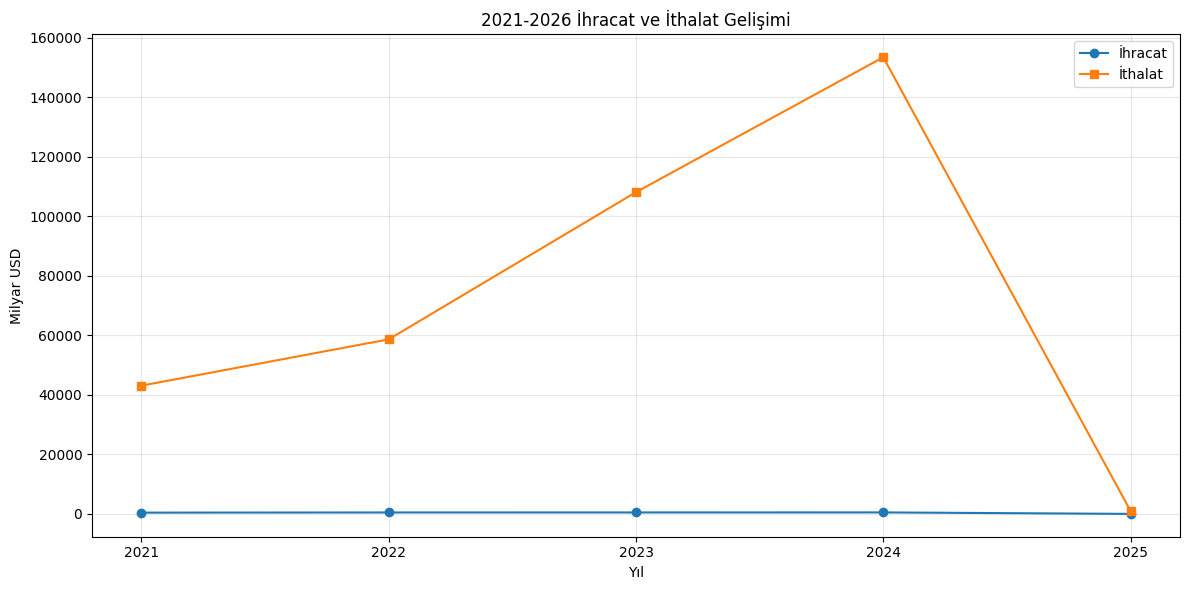

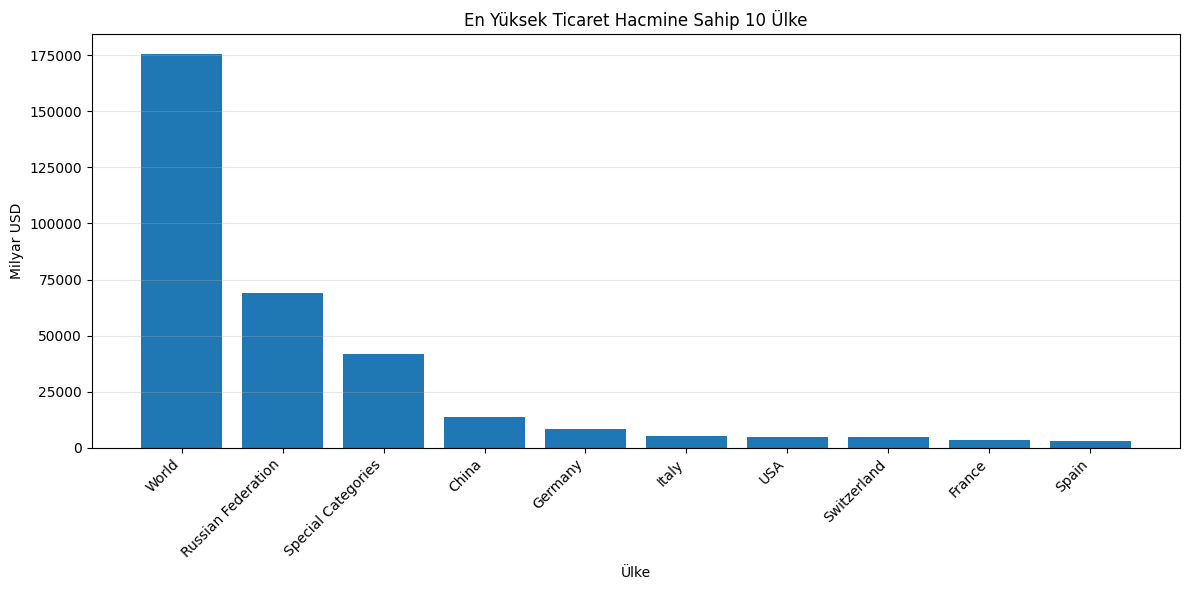

/tmp/ipykernel_4457/3455834019.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


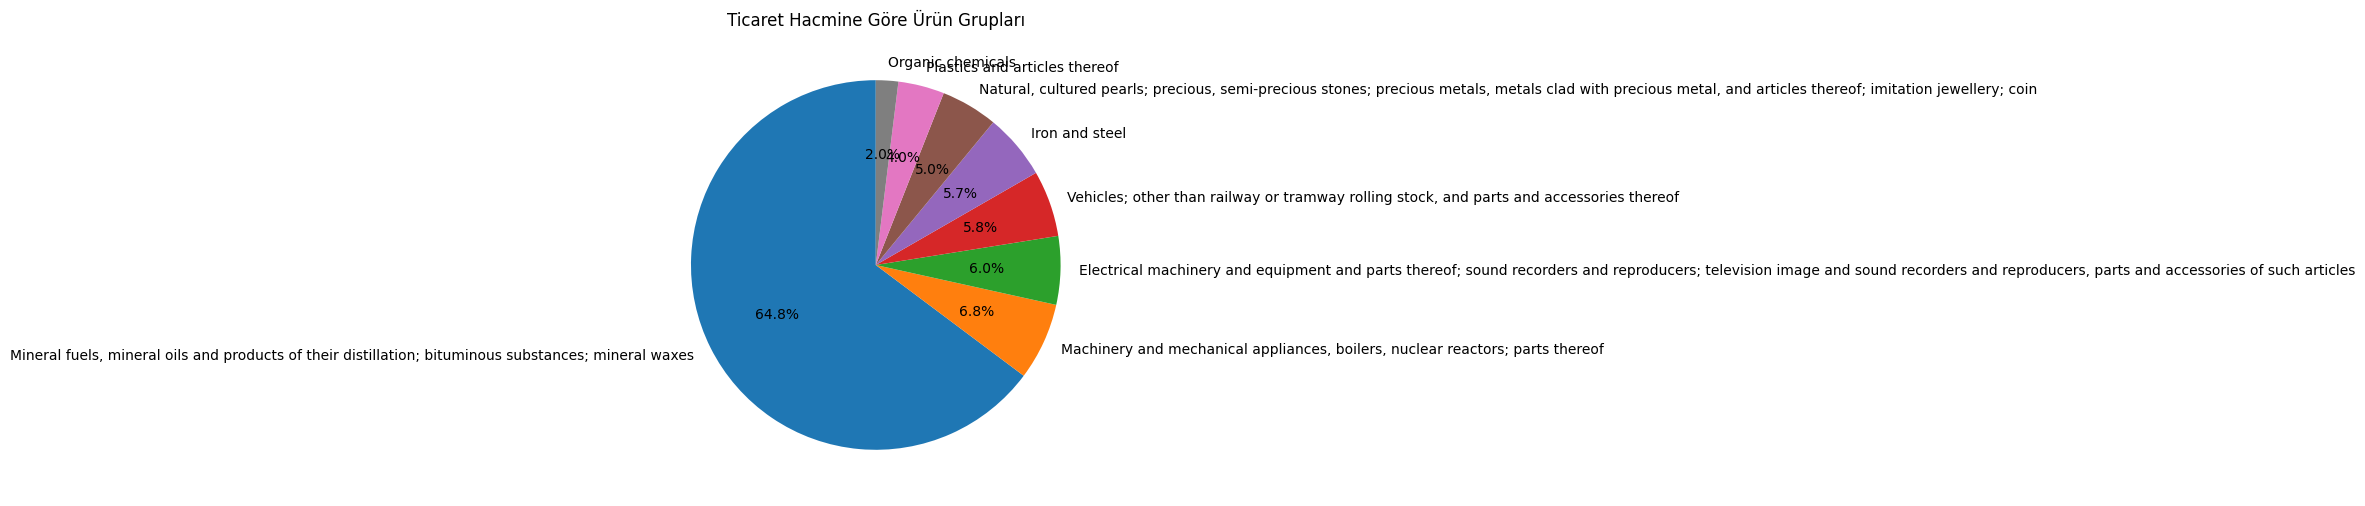

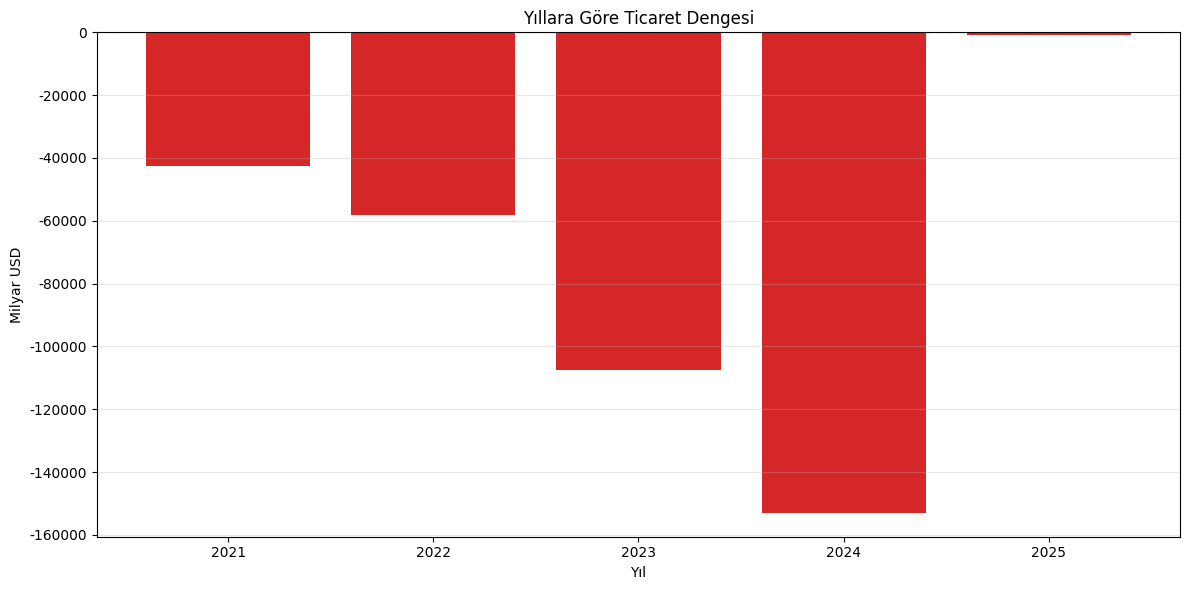

In [12]:
# 1. İhracat - İthalat
ihracat = yillik[yillik["Ticaret_Turu"] == "Export"]
ithalat = yillik[yillik["Ticaret_Turu"] == "Import"]

plt.plot(ihracat["YIL"], ihracat["Milyar"], marker="o", label="İhracat")
plt.plot(ithalat["YIL"], ithalat["Milyar"], marker="s", label="İthalat")
plt.title("2021-2026 İhracat ve İthalat Gelişimi")
plt.xlabel("Yıl")
plt.ylabel("Milyar USD")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. En Büyük 10 Ülke
plt.bar(ulkeler["Ulke"], ulkeler["Milyar"], color="#1f77b4")
plt.title("En Yüksek Ticaret Hacmine Sahip 10 Ülke")
plt.xlabel("Ülke")
plt.ylabel("Milyar USD")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Ürün Dağılımı
plt.pie(urunler["Milyar"], labels=urunler["Urun_Gurubu"], autopct="%1.1f%%", startangle=90)
plt.title("Ticaret Hacmine Göre Ürün Grupları")
plt.tight_layout()
plt.show()

# 4. Ticaret Dengesi
renk = ["#d62728" if x < 0 else "#2ca02c" for x in denge["Milyar"]]
plt.bar(denge["YIL"], denge["Milyar"], color=renk)
plt.axhline(y=0, color="black", linestyle="--")
plt.title("Yıllara Göre Ticaret Dengesi")
plt.xlabel("Yıl")
plt.ylabel("Milyar USD")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()